Processing Venus_Imp5...
Processing Venus_Imp6...
Successfully saved plot: timeseries_Gyr_Tmean.png


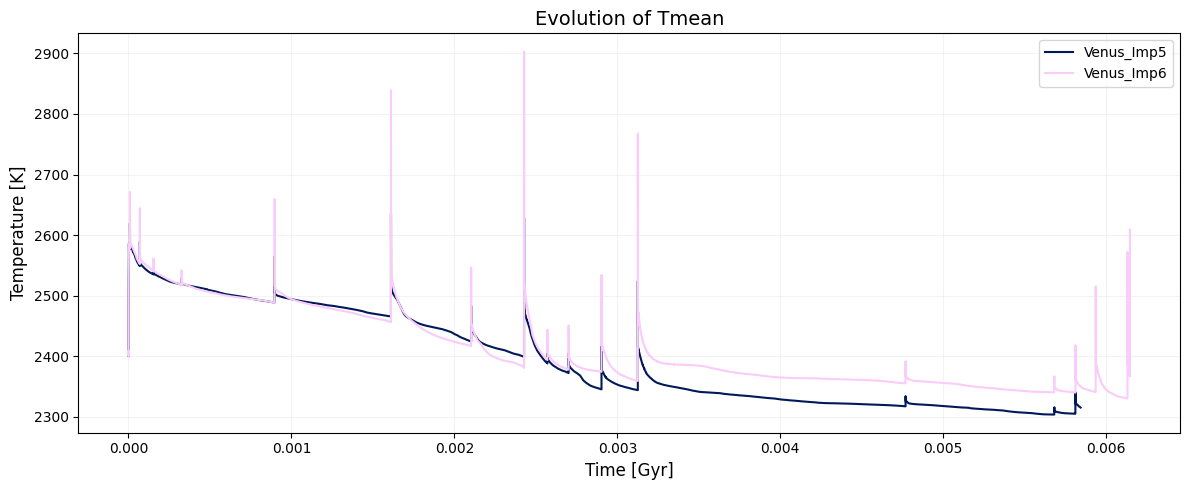

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
from stagpy.stagyydata import StagyyData
from matplotlib.ticker import LogFormatterSciNotation

# Try to import Crameri colormaps; fallback if not installed
try:
    from cmcrameri import cm
    HAS_CRAMERI = True
except ImportError:
    HAS_CRAMERI = False

# --- 1. FULL LIST OF TIME SERIES PARAMETERS ---
ALL_TIME_FIELDS = {
    # Basic Physics & Dynamics
    "time": "Time",
    "dt": "Time increment",
    "dTdt": "Time derivative of temperature",
    "Vmin": "Min velocity",
    "Vrms": "rms velocity",
    "Vmax": "Max velocity",
    "ra_eff": "Effective Ra",
    "mobility": "Plates mobility",
    "ebalance": "Energy balance",

    # Thermal State
    "Tmin": "Min temperature",
    "Tmean": "Temperature",
    "Tmax": "Max temperature",
    "Tsurf": "Temperature at top",
    "Tcmb": "Temperature at bottom",
    "Tpotl": "Mass mean potential temperature",
    "ts_core": "Temperature at core surface",
    "tc_core": "Temperature at center",

    # Heat Flux & Nusselt
    "F_top": "Heat flux at top",
    "F_bot": "Heat flux at bottom",
    "Nu_top": "Nusselt at top",
    "Nu_bot": "Nusselt at bot",

    # Rheology (Viscosity)
    "eta_min": "Min viscosity",
    "eta_amean": "Viscosity (Arithmetic)",
    "eta_max": "Max viscosity",
    "eta_gmean": "Geometric mass mean viscosity",

    # Melting & Volcanism
    "F_mean": "Molten fraction",
    "F_max": "Max molten fraction",
    "erupt_rate": "Eruption rate",
    "erupta": "Erupta total",
    "erupta_total": "Total erupta",
    "erupt_heatflux": "Erupta heat",
    "intruda": "Intruda",
    "H_melt": "Melting heat flux",

    # Heating Sources/Sinks
    "H_int": "Internal heating",
    "H_diffus": "Heat diffusion",
    "H_VD": "Viscous dissipation",
    "H_AH": "Adiabatic heating",
    "H_cool": "Cooling",
    "H_impacts": "Impact heating",

    # Composition & Tracers
    "C_min": "Min concentration",
    "C_mean": "Concentration",
    "C_max": "Max concentration",
    "entrainment": "Entrainment",
    "Cmass_error": "Error on Cmass",
    "denstramin": "Min tracers density",
    "denstramean": "Tracers density",
    "denstramax": "Max tracers density",

    # Volatiles & Noble Gases
    "mH2O_total": "Total H2O mass",
    "mH2O_mantle": "H2O in mantle",
    "outgassed_H2O": "H2O outgassed",
    "outgassed_CO2": "CO2 outgassed",
    "outgassed_N2": "N2 outgassed",
    "outgassed_40Ar": "40Ar outgassed",
    "outgassed_4He": "4He outgassed",
    
    # Core & Geometry
    "r_innercore": "Inner core radius",
    "s_core": "Core size",
    "Psurf": "Ground pressure",
}

# --- 2. CONFIGURATION ---
RUN_PATHS = {
    "Venus_Imp5": "/media/aritro/f522493b-003a-404d-a839-3e0925c674b6/Aritro/StagYY/runs/festus/venus_imp5/archive/",
    "Venus_Imp6": "/media/aritro/f522493b-003a-404d-a839-3e0925c674b6/Aritro/StagYY/runs/festus/venus_imp6/archive/",  
}

field_to_plot = "Tmean"  # Try Vrms or eta_amean

# --- COLOURMAP OPTIONS ---
USE_CRAMERI = True
SEQUENTIAL_MAP = "batlow"  # Used for T, Vrms, Melting, etc.
DIVERGING_MAP  = "vik"     # Used for dTdt, ebalance, H_cool, etc.

# --- 3. PROCESSING LOGIC ---
try:
    fig, ax = plt.subplots(figsize=(12, 5)) 
    labels_set = False
    
    # Pre-determine the colormap based on field type
    # Diverging fields usually involve rates of change, balances, or cooling/flux differences
    is_diverging = any(k in field_to_plot.lower() for k in ["dt", "balance", "cool", "flux", "diff"])
    
    # Sample colors for each run from the chosen map
    num_runs = len(RUN_PATHS)
    line_colors = [None] * num_runs
    
    if USE_CRAMERI and HAS_CRAMERI:
        cmap_obj = getattr(cm, DIVERGING_MAP if is_diverging else SEQUENTIAL_MAP)
        if num_runs > 1:
            line_colors = [cmap_obj(i / (num_runs - 1)) for i in range(num_runs)]
        else:
            line_colors = [cmap_obj(0.5)]

    for idx, (run_label, path_str) in enumerate(RUN_PATHS.items()):
        try:
            print(f"Processing {run_label}...")
            sdata = StagyyData(Path(path_str))
            ts_data = sdata.tseries[field_to_plot]
            
            # Conversion: seconds to Gyr
            time_gyr = ts_data.time / (3.15576e7 * 1e9) 
            values = ts_data.values

            ax.plot(time_gyr, values, label=run_label, linewidth=1.5, color=line_colors[idx])

            if not labels_set:
                description = ts_data.meta.description or ALL_TIME_FIELDS.get(field_to_plot, field_to_plot)
                unit = ts_data.meta.dim
                
                # Manual unit fix for viscosity
                if "eta" in field_to_plot and unit == "Pa": unit = "Pa s"
                
                ax.set_ylabel(f"{description} [{unit}]" if unit else description, fontsize=12)
                ax.set_xlabel("Time [Gyr]", fontsize=12)
                
                # --- AUTO LOG SCALE DETECTION ---
                log_criteria = ["log", "eta", "slog", "visc", "vrms", "vmax", "vmin", "velocity"]
                if any(k in field_to_plot.lower() for k in log_criteria):
                    ax.set_yscale('log')
                    ax.yaxis.set_major_formatter(LogFormatterSciNotation())
                
                labels_set = True

        except Exception as e:
            print(f"Warning: Could not process {run_label}. Error: {e}")
            continue

    ax.legend(loc='best', frameon=True)
    ax.grid(True, which="both", ls="-", alpha=0.15)
    ax.set_title(f"Evolution of {field_to_plot}", fontsize=14)
    plt.tight_layout()

    save_name = f"timeseries_Gyr_{field_to_plot}.png"
    fig.savefig(save_name, dpi=300)
    print(f"Successfully saved plot: {save_name}")
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")